# Survival Analysis

Kaplan-Meier survival curves, log-rank tests, and a Cox Proportional Hazard regression model. Answers *when* customers leave and *which factors* accelerate or delay churn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.insert(0, "..")

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

from src.survival import (
    prepare_survival_data, fit_cox_model,
    plot_kaplan_meier_overall, plot_km_by_group,
    plot_subject_hazard, check_ph_assumption
)

%matplotlib inline
sns.set_style("darkgrid")

### 1. Data Preparation

In [2]:
# Uses MICE imputation + categorical groupings derived from log-rank tests
# See src/survival.py for all grouping decisions
df = prepare_survival_data(
    "../data/E Commerce Dataset.xlsx",
    is_excel=True, sheet_name="E Comm"
)
print(df.shape)
df.head()

(5630, 9)


,Churn,Tenure,NumberOfDeviceRegistered,SatisfactionScore,Complain,PreferredLoginDevice_Phone,PreferredPaymentMode_Debit Card,PreferredPaymentMode_UPI&CreditCard,MaritalStatus_Single
0,1.0,4.000000,3.0,2.0,1.0,1.0,1.0,0.0,1.0
1,1.0,2.456594,4.0,3.0,1.0,1.0,0.0,1.0,1.0
2,1.0,3.046899,4.0,3.0,1.0,1.0,1.0,0.0,1.0
3,1.0,0.010000,4.0,5.0,0.0,1.0,1.0,0.0,1.0
4,1.0,0.010000,3.0,5.0,0.0,1.0,0.0,1.0,1.0


### 2. Overall Kaplan-Meier Curve

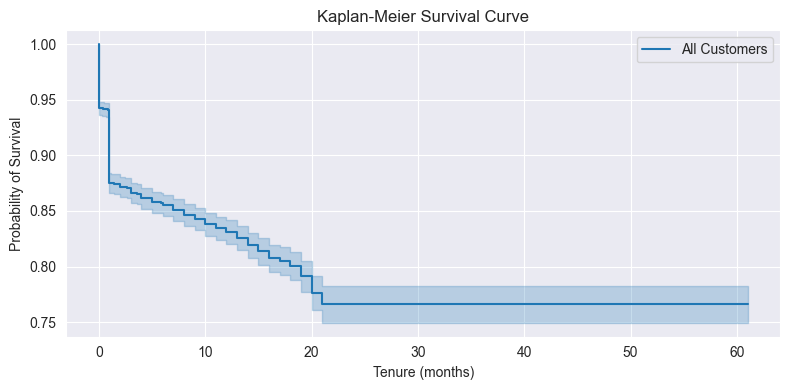

In [ ]:
from src.data_preparation import multiple_imputation

df_raw = pd.read_excel("../data/E Commerce Dataset.xlsx", sheet_name="E Comm")
df_imp = multiple_imputation(df_raw, "Tenure", n_imputations=10)[5]

time = df_imp.Tenure
event = df_imp.Churn

plot_kaplan_meier_overall(time, event)

The survival curve drops steeply in months 0 to 12. After month 24 it flattens, **the first year is the critical retention window.**

### 3. Log-Rank Tests by Categorical Feature

Tests whether survival curves differ significantly across groups.

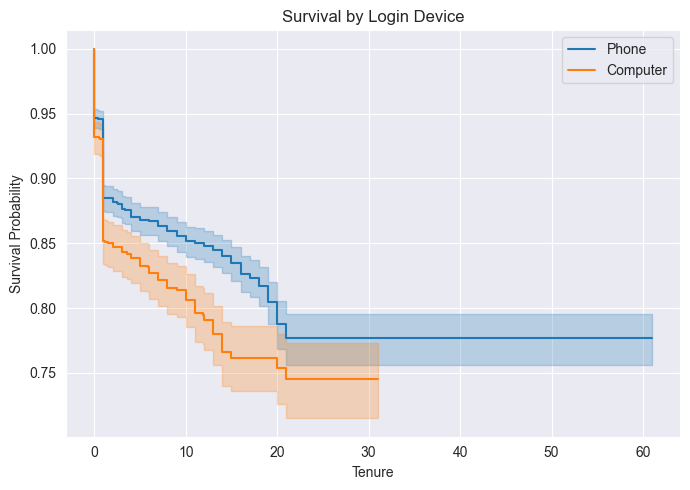

In [6]:
df_imp.PreferredLoginDevice = df_imp.PreferredLoginDevice.replace(
    {"Mobile Phone": "Phone"}
)

plot_km_by_group(time, event, df_imp.PreferredLoginDevice, "Login Device")

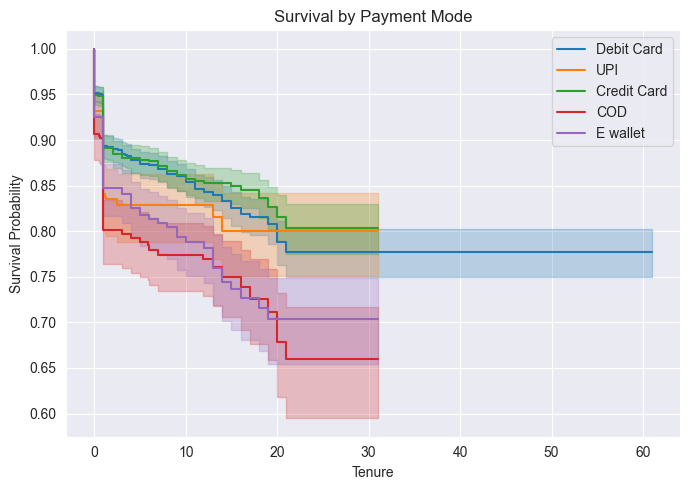

In [7]:
df_imp.PreferredPaymentMode = df_imp.PreferredPaymentMode.replace(
    {"CC": "Credit Card", "Cash on Delivery": "COD"}
)
plot_km_by_group(time, event, df_imp.PreferredPaymentMode, "Payment Mode")

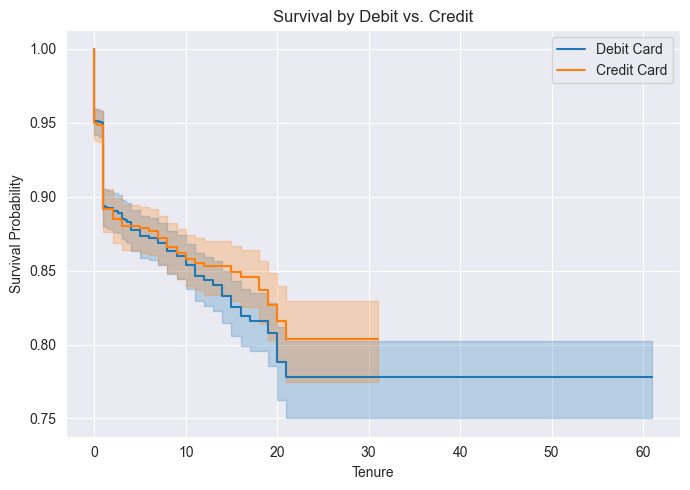

In [12]:
payment_subset1 = df_imp[
    (df_imp.PreferredPaymentMode == "Debit Card")
    | (df_imp.PreferredPaymentMode == "Credit Card")
]
plot_km_by_group(
    payment_subset1.Tenure,
    payment_subset1.Churn,
    payment_subset1.PreferredPaymentMode,
    "Debit vs. Credit",
)

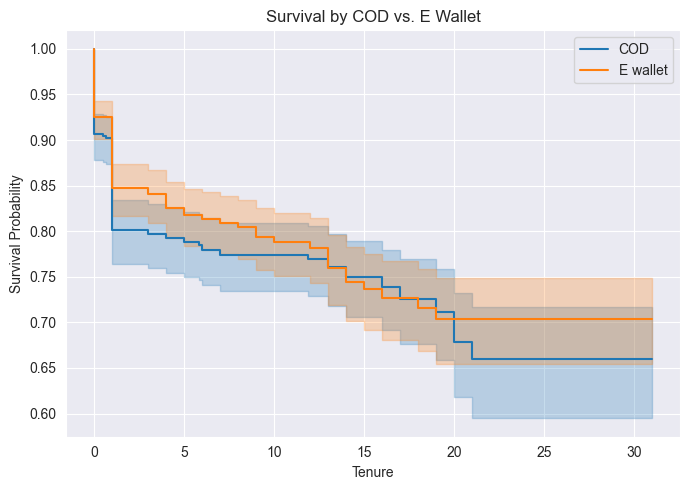

In [14]:
payment_subset2 = df_imp[
    (df_imp.PreferredPaymentMode == "COD") | (df_imp.PreferredPaymentMode == "E wallet")
]
plot_km_by_group(
    payment_subset2.Tenure,
    payment_subset2.Churn,
    payment_subset2.PreferredPaymentMode,
    "COD vs. E Wallet",
)

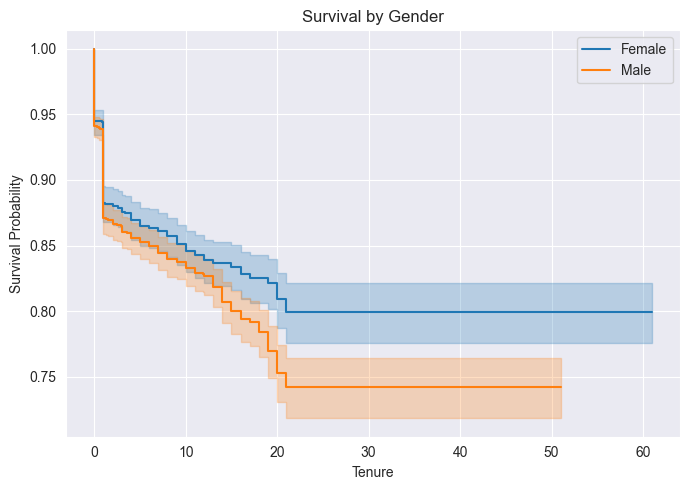

In [8]:
plot_km_by_group(time, event, df_imp.Gender, "Gender")

#### **Order Category**

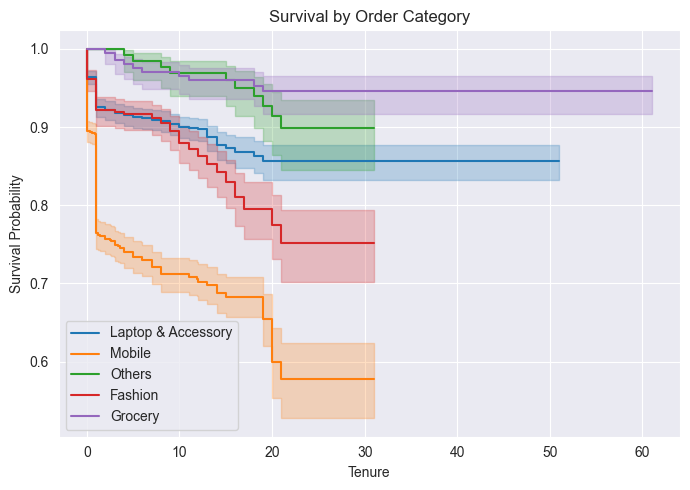

In [10]:
df_imp.PreferedOrderCat = df_imp.PreferedOrderCat.replace({"Mobile Phone": "Mobile"})
plot_km_by_group(time, event, df_imp.PreferedOrderCat, "Order Category")

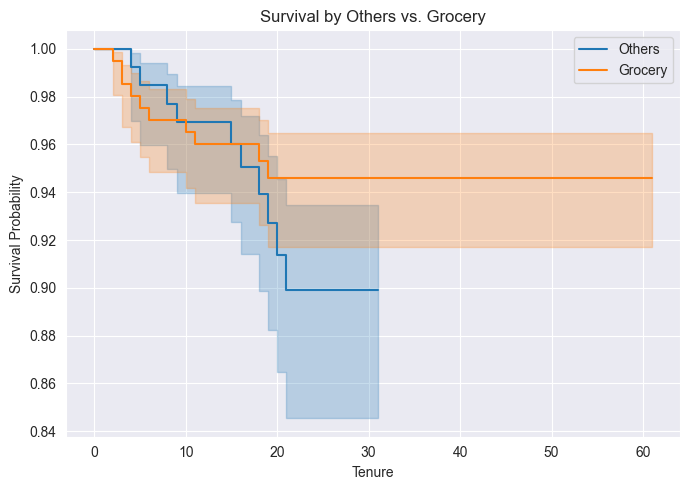

In [15]:
order_subset1 = df_imp[
    (df_imp.PreferedOrderCat == "Others") | (df_imp.PreferedOrderCat == "Grocery")
]
plot_km_by_group(
    order_subset1.Tenure,
    order_subset1.Churn,
    order_subset1.PreferedOrderCat,
    "Others vs. Grocery",
)

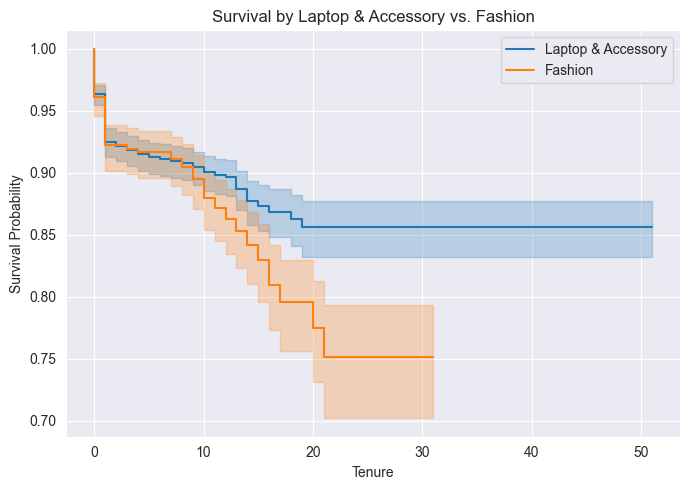

In [16]:
order_subset2 = df_imp[
    (df_imp.PreferedOrderCat == "Laptop & Accessory")
    | (df_imp.PreferedOrderCat == "Fashion")
]
plot_km_by_group(
    order_subset2.Tenure,
    order_subset2.Churn,
    order_subset2.PreferedOrderCat,
    "Laptop & Accessory vs. Fashion",
)

#### **Marital Status**

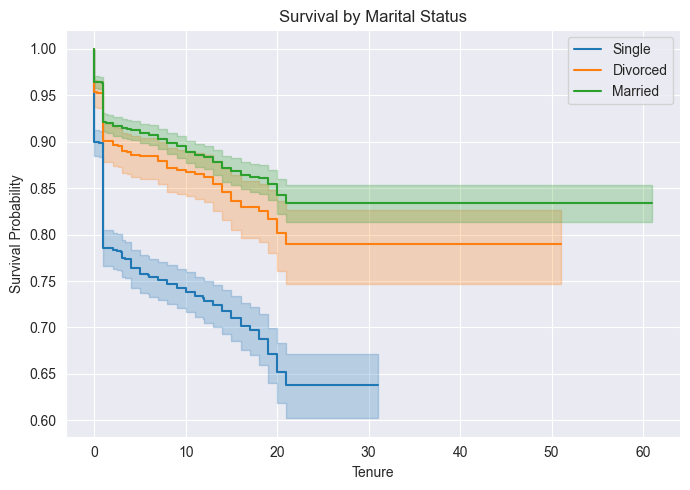

In [11]:
plot_km_by_group(time, event, df_imp.MaritalStatus, "Marital Status")

**Key findings from log-rank tests:**
- Login device groups are distinguishable
- COD/E-Wallet cluster together, Debit/Credit Card cluster together
- Grocery & Others share similar survival
- All three marital status groups are distinguishable

### 4. Cox Proportional Hazard Model

In [17]:
# Initial fit — checks which variables are significant
# NumberOfDeviceRegistered violates PH assumption in the initial fit
# -> resolved by using it as a stratification variable instead
cph = fit_cox_model(df) 

<lifelines.CoxPHFitter: fitted with 5630 total observations, 4682 right-censored observations>
             duration col = 'Tenure'
                event col = 'Churn'
                   strata = NumberOfDeviceRegistered
      baseline estimation = breslow
   number of observations = 5630
number of events observed = 948
   partial log-likelihood = -6225.77
         time fit was run = 2026-03-12 06:20:49 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
SatisfactionScore                    0.21      1.24      0.02            0.16            0.26                1.18                1.30
Complain                             1.18      3.26      0.07            1.06            1.31                2.87                3.71
PreferredLoginDevice_Phone          -0.35      0.71      0.07           -0.48           -0.21                0.62                0.81
PreferredPaymentMode_Debit Card     -0.49      0.61      0.08           -0.65           -0.33                0.52                0.72
PreferredPaymentMode_UPI&CreditCard -0.56      0.57      0.08           -0.72           -0.40                0.49                0.67
MaritalStatus_Single                 0.93      2.54      0.07            0.80            1.06                2.23                2.88

                                     cmp to     z      p  -log2(p)
covariate                                                         
SatisfactionScore                      0.00  8.65 <0.005     57.42
Complain                               0.00 18.13 <0.005    241.68
PreferredLoginDevice_Phone             0.00 -5.00 <0.005     20.71
PreferredPaymentMode_Debit Card        0.00 -6.00 <0.005     28.93
PreferredPaymentMode_UPI&CreditCard    0.00 -6.71 <0.005     35.54
MaritalStatus_Single                   0.00 14.26 <0.005    150.84
---
Concordance = 0.73
Partial AIC = 12463.53
log-likelihood ratio test = 632.96 on 6 df
-log2(p) of ll-ratio test = 440.96

### 5. Proportional Hazard Assumption Check

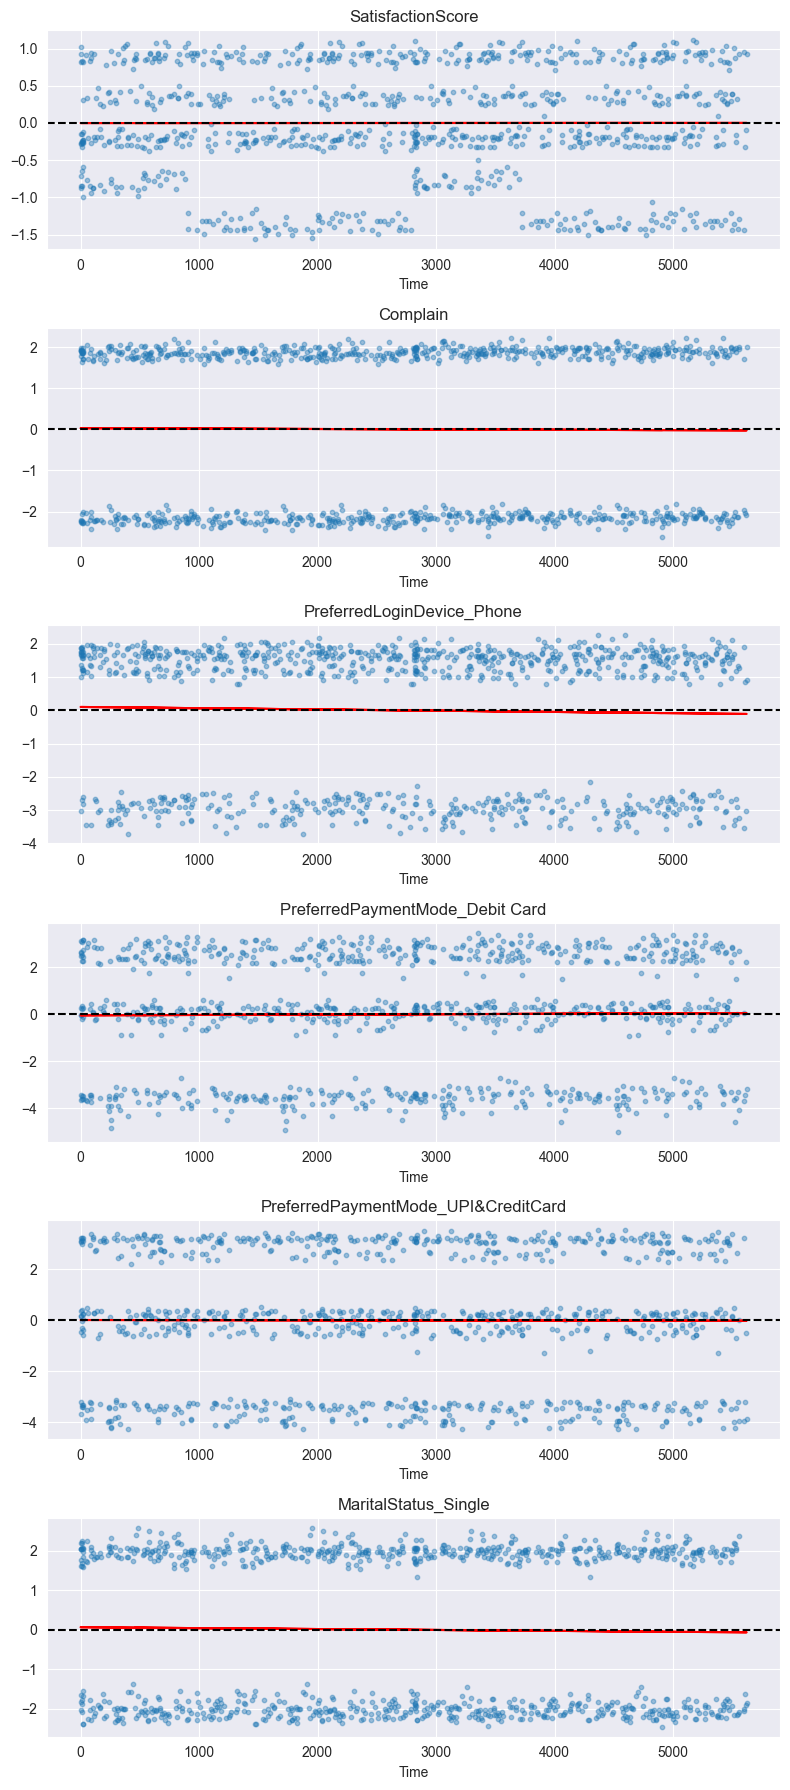

In [18]:
check_ph_assumption(cph, df)

All p-values > 0.05 after stratifying on `NumberOfDeviceRegistered`. The PH assumption holds.

### 6. Individual Prediction

Subject features:
                                     4331
Churn                                 1.0
Tenure                                1.0
NumberOfDeviceRegistered              6.0
SatisfactionScore                     5.0
Complain                              0.0
PreferredLoginDevice_Phone            0.0
PreferredPaymentMode_Debit Card       0.0
PreferredPaymentMode_UPI&CreditCard   0.0
MaritalStatus_Single                  1.0


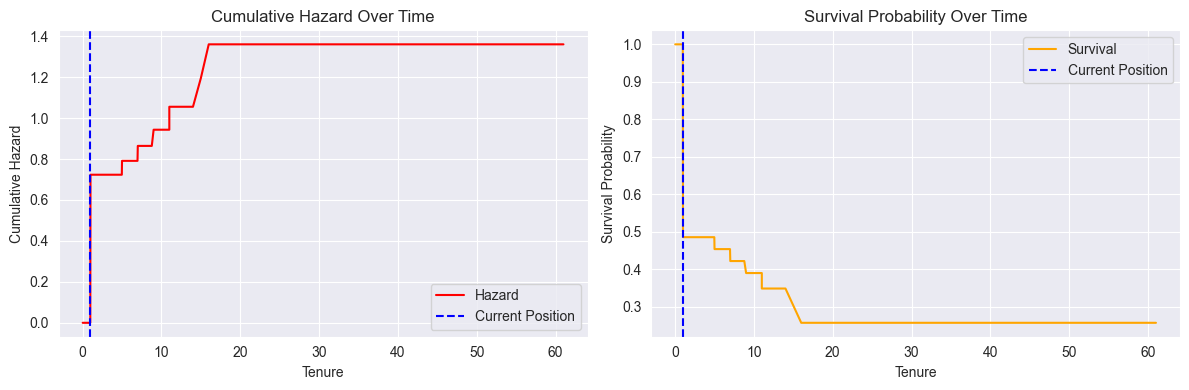

In [19]:
# Sample a random customer and visualise their hazard trajectory
test_subject = df.sample(1, random_state=42)
print("Subject features:")
print(test_subject.T)
plot_subject_hazard(cph, test_subject)

The plot shows cumulative hazard and survival probability over time, with a vertical line marking the customer's current tenure. Customers above the median hazard at their tenure are high-priority retention targets.

### 7. Interpreting Hazard Ratios

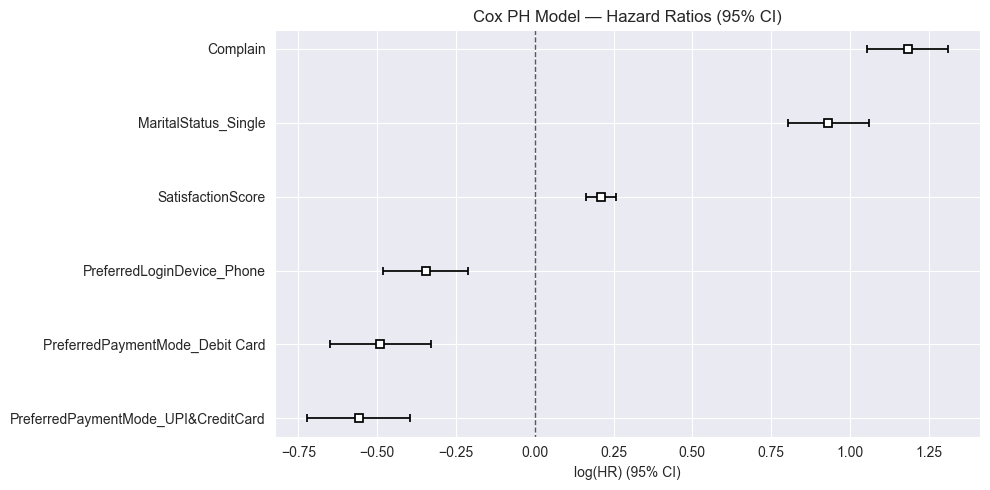

In [20]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
cph.plot(ax=ax)
plt.title("Cox PH Model — Hazard Ratios (95% CI)")
plt.tight_layout()
plt.show()

**Conclusion:**
- **HR > 1:** Covariate *increases* churn hazard (risk factor).
- **HR < 1:** Covariate *decreases* hazard (protective factor).

Higher SatisfactionScore and Complain=1 are consistently among the strongest effects.